In [75]:
import pandas as pd
from sqlalchemy import create_engine

import sys
sys.path.append('../..')
from final_project.scripts.data_analysis_utils import setup_categorical_type

import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

In [76]:
engine = create_engine('sqlite:///../data/database.db')

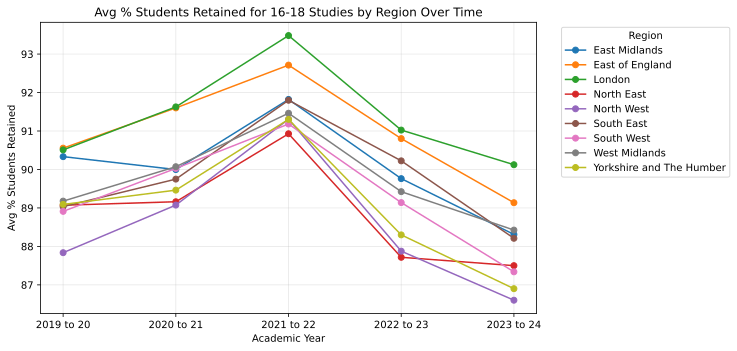

In [77]:
query = """
SELECT time_period, region, AVG(perc_retained) AS avg_perc_retained
FROM retention
GROUP BY region, time_period
ORDER BY time_period, region
"""
pd.read_sql(query, engine)

perc_retained_df = pd.read_sql(query, engine)
pivot_df = perc_retained_df.pivot(index="time_period", columns="region", values="avg_perc_retained")


plt.figure(figsize=(11, 5))
plt.plot(pivot_df, marker="o", label=pivot_df.columns)

plt.xlabel("Academic Year")
plt.ylabel("Avg % Students Retained")
plt.title("Avg % Students Retained for 16-18 Studies by Region Over Time")

plt.grid(True, alpha=0.3)
plt.legend(title="Region", bbox_to_anchor=(1.4, 1), loc="upper right")

plt.tight_layout()
plt.show()

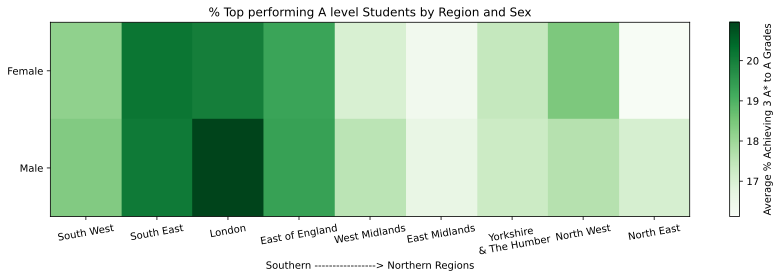

In [78]:
query = """
SELECT
    region,
    characteristic_value AS sex,
    AVG(perc_achieving_3_astar_to_a_grades) AS avg_perc_achieving_top_grades
FROM characteristics
WHERE characteristic_type = 'Sex'
GROUP BY region, characteristic_value
"""
heatmap_df = pd.read_sql(query, engine)

pivot_heatmap = heatmap_df.pivot(index="sex", columns="region", values="avg_perc_achieving_top_grades")
rearranged_df = pivot_heatmap[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                               "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df.rename(columns={"Yorkshire and The Humber": "Yorkshire\n & The Humber"}, inplace=True)

plt.figure(figsize=(12, 4))

plt.imshow(rearranged_df, cmap='Greens', aspect='auto')
plt.colorbar(label="Average % Achieving 3 A* to A Grades")

plt.xticks(ticks=range(len(rearranged_df.columns)), labels=rearranged_df.columns, rotation=10)
plt.yticks(ticks=range(len(rearranged_df.index)), labels=rearranged_df.index)
plt.title("% Top performing A level Students by Region and Sex")
plt.xlabel("Southern -----------------> Northern Regions")

plt.tight_layout()
plt.show()

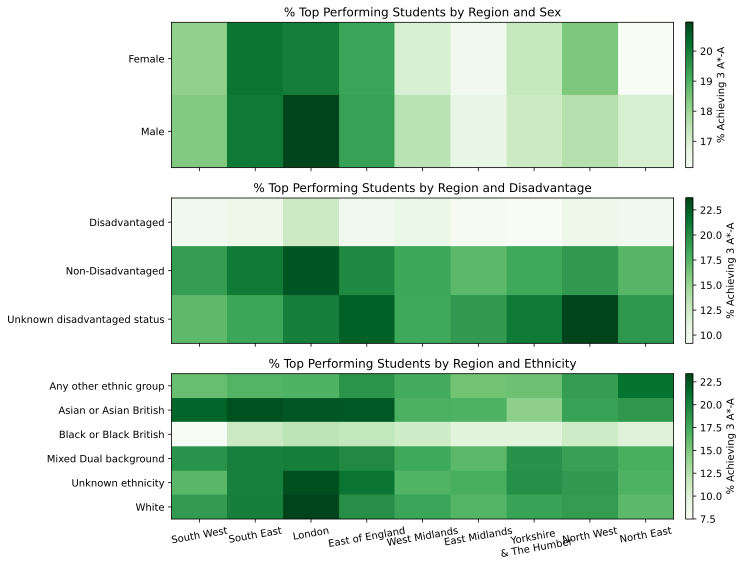

In [112]:
# Characteristic types
characteristic_types = ["Sex", "Disadvantage", "Ethnicity"]

# Consistent region ordering
region_order = [
    "South West", "South East", "London", "East of England", "West Midlands",
    "East Midlands", "Yorkshire and The Humber", "North West", "North East"
]

# Prepare data frames
heatmaps = []
vmin, vmax = None, None  # Will determine global min/max for color scaling

for char_type in characteristic_types:
    query = f"""
        SELECT
            region,
            characteristic_value,
            AVG(perc_achieving_3_astar_to_a_grades) AS avg_top_grades
        FROM characteristics
        WHERE characteristic_type = '{char_type}'
        GROUP BY region, characteristic_value
    """
    df = pd.read_sql(query, engine)

    # Pivot & rename
    pivot_df = df.pivot(index="characteristic_value", columns="region", values="avg_top_grades")
    pivot_df = pivot_df[[r for r in region_order if r in pivot_df.columns]]  # Ensure column order
    pivot_df = pivot_df.rename_axis(None, axis=0).rename_axis(None, axis=1)
    pivot_df.rename(columns={"Yorkshire and The Humber": "Yorkshire\n & The Humber"}, inplace=True)
    heatmaps.append(pivot_df)


#     # Track min/max for global color scale
#     vmin = pivot_df.min().min() if vmin is None else min(vmin, pivot_df.min().min())
#     vmax = pivot_df.max().max() if vmax is None else max(vmax, pivot_df.max().max())

# # Plotting with shared colorbar
# fig, axes = plt.subplots(len(characteristic_types), 1, figsize=(11, 9), sharex=True)
# fig.subplots_adjust(right=0.85, hspace=0.4)

# for i, (pivot_df, ax) in enumerate(zip(heatmaps, axes)):
#     im = ax.imshow(pivot_df.values, aspect='auto', cmap="Greens", vmin=vmin, vmax=vmax)
#     ax.set_title(f"% Achieving 3 A*-A Grades by Region and {characteristic_types[i]}", fontsize=12)
#     ax.set_yticks(range(len(pivot_df.index)))
#     ax.set_yticklabels(pivot_df.index)
#     ax.set_xticks(range(len(pivot_df.columns)))
#     ax.set_xticklabels(pivot_df.columns, rotation=10)

# # Shared colorbar
# cbar_ax = fig.add_axes([0.88, 0.3, 0.02, 0.4])
# fig.colorbar(im, cax=cbar_ax, label="% Achieving Top Grades", cmap="Greens")

# plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.show()

###############################################################################################

# Plotting with individual colorbars
fig, axes = plt.subplots(len(characteristic_types), 1, figsize=(11, 8), sharex=True)
fig.subplots_adjust(hspace=0.6)

for i, (pivot_df, ax) in enumerate(zip(heatmaps, axes)):
    im = ax.imshow(pivot_df.values, aspect='auto', cmap="Greens", vmin=vmin, vmax=vmax)
    ax.set_title(f"% Top Performing Students by Region and {characteristic_types[i]}", fontsize=12)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, rotation=10)

    # Individual colorbar beside each heatmap
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label("% Achieving 3 A*-A")

plt.tight_layout()
plt.show()

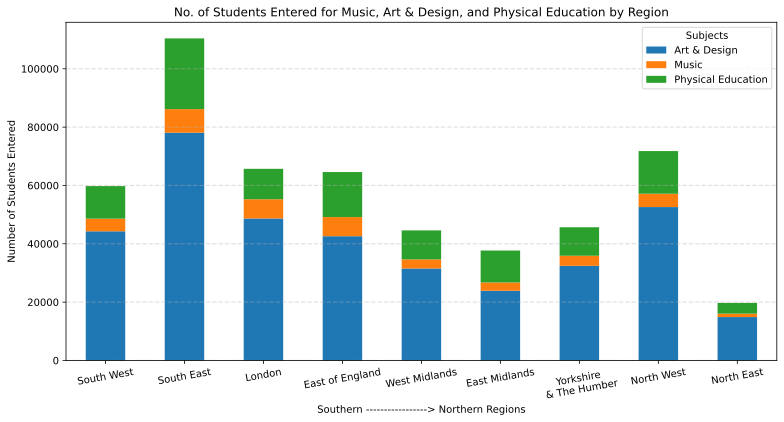

In [80]:
query = """
SELECT
    region,
    subject_area AS subject,
    SUM(number_of_students_entered) AS total_students_entered
FROM results
WHERE subject = 'Music' OR subject = 'Art & Design' OR subject = 'Physical Education'
GROUP BY region, subject
"""
subject_df = pd.read_sql(query, engine)

pivot_subject_df = subject_df.pivot(index="subject", columns="region", values="total_students_entered")
rearranged_df = pivot_subject_df[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

rearranged_df.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6)
)

plt.ylabel("Number of Students Entered")
plt.xlabel("Southern -----------------> Northern Regions")
plt.title("No. of Students Entered for Music, Art & Design, and Physical Education by Region")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', linewidth=1.2, alpha=0.4)
plt.legend(title="Subjects", loc="upper right")

plt.tight_layout()
plt.show()

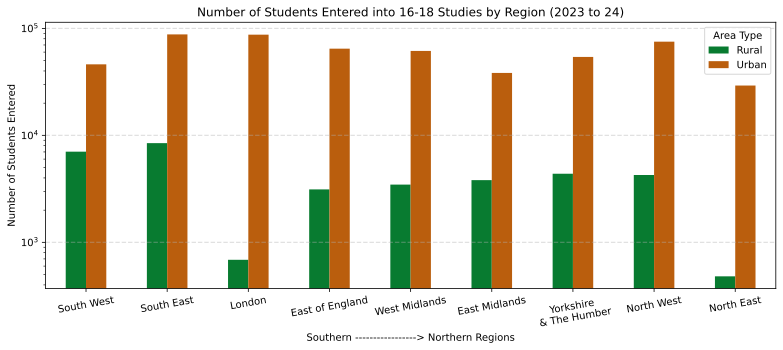

In [150]:
query = """
SELECT
    region,
    CASE
        WHEN rurality LIKE '%Rural%' THEN 'Rural'
        WHEN rurality LIKE '%Urban%' THEN 'Urban'
    END AS rurality_type,
    SUM(number_of_students_completed) AS total_students
FROM rurality
WHERE time_period = '2023 to 24'
GROUP BY region, rurality_type
ORDER BY region, rurality_type
"""
rurality_comp_df = pd.read_sql(query, engine)

pivot_rurality = rurality_comp_df.pivot(index="rurality_type", columns="region", values="total_students")
rearranged_df = pivot_rurality[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

colour_map = {'Rural': "#087B30", 'Urban': "#ba5e0d"}  # blue & orange

rearranged_df.plot(
    kind='bar',
    stacked=False,
    figsize=(11, 5),
    color=[colour_map[col] for col in rearranged_df.columns]
)

plt.yscale("log")
plt.ylabel("Number of Students Entered")
plt.xlabel("Southern -----------------> Northern Regions")
plt.title("Number of Students Entered into 16-18 Studies by Region (2023 to 24)")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', linewidth=1.2, alpha=0.4)
plt.legend(title="Area Type", loc="upper right")

plt.tight_layout()
plt.show()


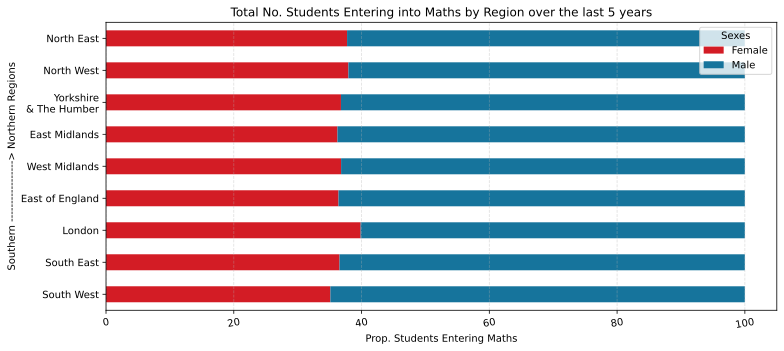

In [153]:
query = """
SELECT
    region,
    sex,
    SUM(number_of_students_entered) AS avg_entered
FROM stem
WHERE sex IN ('Male', 'Female')
    AND subject_combination LIKE '%math%'
GROUP BY region, sex
"""
stem_df = pd.read_sql(query, engine)

pivot_stem_df = stem_df.pivot(index="sex", columns="region", values="avg_entered")
rearranged_df = pivot_stem_df[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

# Convert counts to proportions per region
prop_df = rearranged_df.div(rearranged_df.sum(axis=1), axis=0)

# Optionally multiply by 100 for percentage bars
prop_df *= 100

colour_map = {'Male': "#16749C", 'Female': "#d31c25"}  # blue & orange

prop_df.plot(
    kind='barh',
    stacked=True,
    figsize=(11, 5),
    color=[colour_map[col] for col in prop_df.columns]
)

plt.xlabel("Prop. Students Entering Maths")
plt.ylabel("Southern -----------------> Northern Regions")
plt.title("Total No. Students Entering into Maths by Region over the last 5 years")
plt.xticks(rotation=10)

plt.grid(axis="x", linestyle='--', alpha=0.4)
plt.legend(title="Sexes", loc="upper right")

plt.tight_layout()
plt.show()


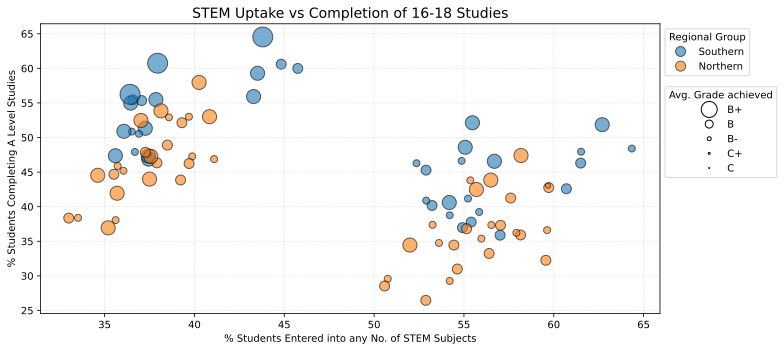

In [201]:
query = """
SELECT
    s.region,
    s.time_period,
    s.sex,
    SUM(s.perc_entered_comb) AS perc_students_entered_stem,
    c.perc_completing_a_levels,
    c.average_a_level_grade
FROM stem AS s
JOIN characteristics AS c
    ON s.region = c.region
    AND s.time_period = c.time_period
    AND s.sex = c.characteristic_value
WHERE c.characteristic_type = 'Sex'
GROUP BY s.region, s.time_period, s.sex
ORDER BY perc_students_entered_stem DESC
"""
merged_df = pd.read_sql(query, engine)

convert_grades = {'B+': 400, 'B': 200, 'B-': 100, 'C+': 50, 'C': 25}
merged_df['average_a_level_grade_value'] = merged_df["average_a_level_grade"].map(convert_grades)

convert_regions = {
    "South West": "Southern",
    "South East": "Southern",
    "London": "Southern",
    "East of England": "Southern",
    "West Midlands": "Northern",
    "East Midlands": "Northern",
    "Yorkshire and The Humber": "Northern",
    "North West": "Northern",
    "North East": "Northern"
}
merged_df['regional_group'] = merged_df['region'].map(convert_regions)

colour_map = {'Southern': '#1f77b4', 'Northern': '#ff7f0e'}  # blue & orange

fig, ax = plt.subplots(figsize=(11, 5))
for regional_group in merged_df['regional_group'].unique():
    data = merged_df[merged_df['regional_group'] == regional_group]
    ax.scatter(
        data['perc_students_entered_stem'],
        data['perc_completing_a_levels'],
        s=data['average_a_level_grade_value'],
        alpha=0.6,
        c=colour_map[regional_group],
        label=regional_group,
        edgecolor='k'
    )

# Labels and title
ax.set_xlabel("% Students Entered into any No. of STEM Subjects")
ax.set_ylabel("% Students Completing A Level Studies")
ax.set_title("STEM Uptake vs Completion of 16-18 Studies", fontsize=14)

handles1 = [
    plt.Line2D([], [], color='w', marker='o', markerfacecolor=colour_map[regional_group], alpha=0.6, 
                  markeredgecolor='k', markersize=10, label=regional_group) 
                  for regional_group in merged_df['regional_group'].unique()
]
legend1 = plt.legend(handles=handles1, title="Regional Group", loc="upper left", bbox_to_anchor=(1, 1))
plt.gca().add_artist(legend1)

handles2 = [
    plt.Line2D([], [], color='w', marker='o', markerfacecolor="white",
                  markeredgecolor='k', markersize=convert_grades[grade], label=grade) 
                  for grade in convert_grades.keys()
]
plt.legend(handles=handles2, title="Avg. Grade achieved", loc="upper left", bbox_to_anchor=(1, 0.8), markerscale=0.04)


# ax.legend(title="Regional Group", loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
query = """
SELECT
    s.region,
    s.time_period,
    s.sex,
    SUM(s.perc_entered_comb) AS perc_students_entered_stem,
    c.perc_completing_a_levels,
    c.average_a_level_grade
FROM stem AS s
JOIN characteristics AS c
    ON s.region = c.region
    AND s.time_period = c.time_period
    AND s.sex = c.characteristic_value
WHERE c.characteristic_type = 'Sex'
GROUP BY s.region, s.time_period, s.sex
ORDER BY perc_students_entered_stem DESC
"""
merged_df = pd.read_sql(query, engine)



In [ ]:
rurality_df["dropout_rate"] = (rurality_df["number_of_students_entered"] - 
                               rurality_df["number_of_students_potential"])/ rurality_df["number_of_students_entered"]

In [ ]:
chars_df.groupby("region_name").apply(lambda x: x.isnull().sum(), include_groups=False)

In [ ]:
chars_df[chars_df["number_of_students_potential"].isnull()]

In [ ]:
chars_df["characteristic_type"].unique()

In [74]:
engine.dispose()